In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Analysis_Data.xlsx to Analysis_Data (3).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm

In [ ]:
#read in data
projections = pd.read_excel('Analysis_Data.xlsx', header=2, sheet_name='Price Projections')
data = pd.read_excel('Analysis_Data.xlsx', header=2, sheet_name='Drilling Cost')

<h2>Part 1</h2>

<p>The probability of a well producing is 85%. The number of planned wells in a project is assumed to be a Uniform distribution between 10 and 30</p>

<ol>
<li>Run a simulation for the number of wells in the project that includes whether the well is producing or dry.</li>
<li>Provide a histogram of the distribution of the proportion of wells that is producing – you will need to know how many wells are dry and how many are producing for each simulation to calculate this.</li>
</ol>

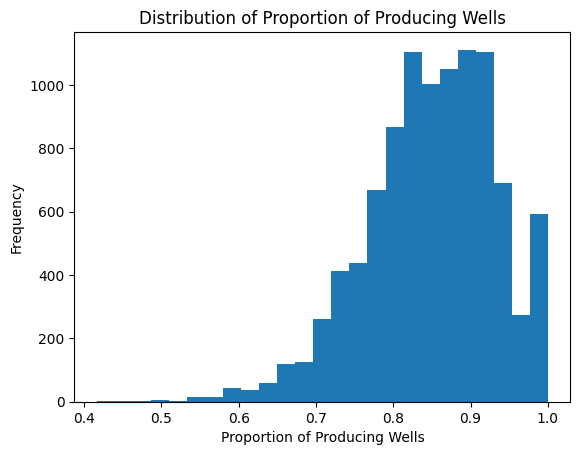

Mean proportion producing: 0.8499219278041653
Min: 0.4166666666666667
Max: 1.0


In [ ]:
SEED = 123456
rng = np.random.default_rng(SEED)
n_sim = 10000

proportion_producing = []

#simulation is run 10000 times
for i in range(n_sim):

    #number of planned wells in the project is a uniform distribution between 10 and 30
    num_wells = rng.integers(10, 31)

    #these is where we simulate if the well is producing (1) or not producing (0)
    wells = rng.binomial(1, 0.85, size=num_wells)

    #gets the proportion of wells that are producing in this simulation
    prop = np.mean(wells)

    #append the proportion to the list holding the results from the 10000 simulations
    proportion_producing.append(prop)

#create histogram of results
plt.hist(proportion_producing, bins=25)
plt.xlabel("Proportion of Producing Wells")
plt.ylabel("Frequency")
plt.title("Distribution of Proportion of Producing Wells")
plt.show()

#some summary stats (not needed for anything specifically in assignment)
print("Mean proportion producing:", np.mean(proportion_producing))
print("Min:", np.min(proportion_producing))
print("Max:", np.max(proportion_producing))

<h2>Part 2</h2>

<p>Once these pieces of the RFP are complete, the combined results (Your previous responses to Phase 1) can form the whole understanding of the net present value across the entire project. You can refer to your previous report in this final report as necessary and you should use your previous work to estimate costs for each run of the simulations you create.</p>

<ul>
<li>Simulate the distribution of Net Present Value from the entire project (all of the wells).</li>
<li>Calculate the expected return from the scenario, as well as measures of risk – such as Value at Risk and Expected Shortfall.</li>
</ul>

<p>Note: you will need to calculate the NPV of producing and dry wells in order to determine the NPV of each simulation (details below). Do the NPV calculation assuming 15 years of production for wells that produce.</p>

<p>Make a recommendation on whether the company should invest in the scenario described based on your above numbers.</p>

In [ ]:
##Bring in work from hw 1 data reformatting

#limit data to only be from 1990-2006
data = data[(data['Date']>'1990-06-30')&(data['Date']<'2007-06-30')].reset_index(drop=True)

#get average cost in 2006 for starting point
P0 = data.iloc[15, [1, 2, 3]].mean()

#reformatting the data
#pivot data into long format to make the 48 observations
data = pd.melt(data,
                  id_vars=['Date'],
                  value_vars=['Arithmetic Return - Crude Oil', 'Arithmetic Return - Natural Gas', 'Arithmetic Return - Dry Well'],
                  var_name='Well Type',
                  value_name='Change')

#sort by date and well type
data = data.sort_values(by=['Date','Well Type'], ascending=True).reset_index(drop=True)

#get rid of the 'arithmetic return -' substring before the well type
data['Well Type'] = data['Well Type'].str.replace('Arithmetic Return - ', '')

<h3>Base Case NPV Model</h3>

<p>This uses the mean/most likely value for all distributions. The only part that still had distributions involved was the work from hw 1.</p>

In [ ]:
##Get drilling costs from hw 1

#normal distribution for 2006-2012
years = 6

mu = data['Change'].to_numpy().mean()
sigma = data['Change'].to_numpy().std()

r_6 = rng.normal(loc=mu, scale=sigma, size=(n_sim, years))
P6_normal = P0 * np.prod(1 + r_6, axis=1)

#2012 - 2015
sim_12_15 = rng.uniform(-0.22, -0.07, size=(n_sim, 3))

#2015 - 2024
sim_15_24 = rng.uniform(0.02, 0.06, size=(n_sim, 9))

#2025
sim_25 = rng.uniform(0.02, 0.06, size=(n_sim, 1))

#concatenate these into an array
future_changes = np.concatenate([sim_12_15, sim_15_24, sim_25], axis=1)

#simulation with normal distribution for 2006-2012 time period
P2025_normal = P6_normal * np.prod(1 + future_changes, axis=1)


#use mean as drilling cost (multiply by 1000 since this is in $000s)
drilling_cost_2025 = float(np.mean(P2025_normal)) * 1000

In [ ]:
##Year 0 costs

lease_cost = 600 * 960
seismic_cost = 3 * 43000
completion = 390000
overhead = 215000

year0_cost = drilling_cost_2025 + lease_cost + seismic_cost + overhead + completion
print(year0_cost)

5749238.352403917


In [ ]:
##Production Risk

ip = 420
decline = 0.235

#determining production rate for each year (calculation is from hw document) - did life+2 to get rate at year end of 15 / year begin of 16 since oil is produced for 15 years according to hw
rates = [ip]
for year in range(1, 16):
    rates.append((1-decline)*rates[-1])
print(rates)
print(len(rates))

#determining yearly production volume in barrels of oil (calculation is in hw document)
oil_prod = []
for year in range(1, 16):
    oil_prod.append(365*((rates[year-1]+rates[year])/2))
print(oil_prod)
print(len(oil_prod))

[420, 321.3, 245.7945, 188.0327925, 143.8450862625, 110.04149099081249, 84.18174060797156, 64.39903156509824, 49.265259147300156, 37.68792324768462, 28.831261284478735, 22.055914882626233, 16.87277488520907, 12.907672787184937, 9.874369682196477, 7.553892806880305]
16
[135287.25, 103494.74625000001, 79173.48088125, 60567.712874156256, 46334.30034872953, 35445.73976677809, 27115.990921585242, 20743.733055012708, 15868.955787084722, 12139.751177119813, 9286.909650496656, 7104.485882629942, 5434.931700211906, 4157.722750662108, 3180.6579042565127]
15


In [ ]:
##Revenue Risk

#determining oil price per barrel for each year (from projections data, which has a low, high, and typical value - using triangular distribution because of this)
prices = []
for year in range(1, 16):
    price = projections.loc[year-1]['AEO2023 Reference']
    prices.append(price)
print(prices)
print(len(prices))

#determining net revenue interest (percentage of oil revenue retained after paying all royalties) - done per well for entire lifetime so should only be one value
nri = 0.75
revenues = []
for year in range(1, 16):
    year_revenue = oil_prod[year-1]*prices[year-1]*nri
    revenues.append(year_revenue)
print(revenues)
print(len(revenues))

[np.float64(85.255096), np.float64(85.532898), np.float64(86.264732), np.float64(86.738144), np.float64(87.188271), np.float64(87.748749), np.float64(88.512123), np.float64(88.937447), np.float64(89.608727), np.float64(90.03215), np.float64(90.825806), np.float64(91.434029), np.float64(91.807198), np.float64(92.341896), np.float64(92.759918)]
15
[np.float64(8650445.6147445), np.float64(6639154.18090285), np.float64(5122409.332296116), np.float64(3940148.2507719146), np.float64(3029855.6515503186), np.float64(2332739.4914357467), np.float64(1800070.4427886773), np.float64(1383670.9943717557), np.float64(1066497.6951749586), np.float64(819725.9242058457), np.float64(632618.2906916528), np.float64(487193.8261668575), np.float64(374224.3880383733), np.float64(287949.0013788558), np.float64(221278.1747886645)]
15


In [ ]:
##Operating Expenses

#determining total yearly operating cost
all_operating_costs = []
for year in range(1, 16):
    all_operating_costs.append(2.25*oil_prod[year-1])
print(all_operating_costs)
print(len(all_operating_costs))

#determining total yearly taxes (applied after nri)
taxes = []
for year in range(1, 16):
    taxes.append(0.046*revenues[year-1])
print(taxes)
print(len(taxes))

[304396.3125, 232863.1790625, 178140.3319828125, 136277.35396685157, 104252.17578464144, 79752.9144752507, 61010.979573566794, 46673.39937377859, 35705.150520940624, 27314.44014851958, 20895.546713617478, 15985.093235917371, 12228.596325476788, 9354.876188989743, 7156.480284577154]
15
[np.float64(397920.49827824696), np.float64(305401.0923215311), np.float64(235630.82928562135), np.float64(181246.81953550808), np.float64(139373.35997131464), np.float64(107306.01660604434), np.float64(82803.24036827915), np.float64(63648.865741100766), np.float64(49058.893978048094), np.float64(37707.3925134689), np.float64(29100.44137181603), np.float64(22410.916003675444), np.float64(17214.321849765172), np.float64(13245.654063427366), np.float64(10178.796040278567)]
15


In [ ]:
##Cash Flows Calculation

#determining yearly cash flows
cash_flows = []
for year in range(1, 16):
    cash_flows.append(revenues[year-1]-all_operating_costs[year-1]-taxes[year-1]-overhead)
print(cash_flows)

[np.float64(7733128.803966252), np.float64(5885889.909518819), np.float64(4493638.171027682), np.float64(3407624.0772695546), np.float64(2571230.1157943625), np.float64(1930680.5603544516), np.float64(1441256.2228468314), np.float64(1058348.7292568763), np.float64(766733.6506759698), np.float64(539704.0915438572), np.float64(367622.3026062193), np.float64(233797.81692726468), np.float64(129781.46986313135), np.float64(50348.4711264387), np.float64(-11057.101536191214)]


In [ ]:
##NPV Calculation

#determining discounted sums of revenues and expenses for each year
yearly_sum = []
for year in range(1, 16):
    yearly_sum.append(cash_flows[year-1]/((1+0.1)**year))
print(yearly_sum)

#getting npv for well
npv = -year0_cost + sum(yearly_sum)
print(npv)

[np.float64(7030117.094514774), np.float64(4864371.82604861), np.float64(3376136.867789392), np.float64(2327453.0956010884), np.float64(1596531.60538858), np.float64(1089818.843581706), np.float64(739592.3312043757), np.float64(493727.4930339254), np.float64(325169.9151777193), np.float64(208079.29077239567), np.float64(128849.37437678217), np.float64(74495.18958643057), np.float64(37593.06896921957), np.float64(13258.326054118541), np.float64(-2646.982196831739)]
16553308.987498373


In [ ]:
##Entire Project NPV

base_npv = npv * 20 #for average of 20 wells in project (all producing)
print(base_npv)

331066179.74996746


<h3>Monte Carlo Simulation of NPV</h3>

<p>The function below simulates the npv for a SINGLE WELL</p>

<p>NOTE: operating costs (not including taxes) are NOT calculated in this function/code block (simulate_well_npv), instead they are calculated in the following code block which calculates the NPV for the entire project. This is because the operating costs are the same for EVERY WELL in a given year, but can vary from year to year. Since then following function only calculates npv for a single well, it made sense to create an array of yearly operating costs for the entire project, and that is then passed in as operating costs to the simulate_well_npv function.</p>

In [ ]:
def simulate_well_npv(drilling_cost, producing, operating_costs):
    LIFE = 15
    WACC = 0.10
    SEVERANCE_TAX = 0.046

    ##Year 0 Expenses

    #determining lease costs
    #leased acres per well are normally distributed with mean of 600 acres per well and standard deviation of 50 acres per well
    acres = rng.normal(600, 50)
    #price per acre is $960
    lease_cost = acres * 960

    #determining seismic costs
    #number of seismic sections per well are normally distributed with mean of 3 sections per well and standard deviation of 0.35 sections per well
    sections = rng.normal(3, 0.35)
    #seismic cost per section is $43,000
    seismic_cost = sections * 43_000

    #determining completion costs
    #if producing then engineers prepare well to produce oil, and cost for this is normally distributed with mean of $390,000 and standard deviation of $50,000
    if producing:
        completion = rng.normal(390000, 50000)
    else:
        completion = 0

    #determining professional overhead for year 0 (there will also be overhead for following years depending on if dry or producing)
    #salary and benefit cost is represented by triangular distribution with most likely of $215,000, minimum of $172,000, and maximum of $279,500
    overhead = rng.triangular(172000, 215000, 279500)

    #calculate total year 0 expenses
    year0_cost = drilling_cost + lease_cost + seismic_cost + completion + overhead


    ##if the well is not producing then only the initial costs are incurred
    if not producing:
        return -year0_cost


    ##Production Risk

    #correlation coefficient between ip and decline (from hw document)
    rho = 0.64

    #create correlation structure
    cov_matrix = [[1, rho],[rho, 1]]

    #generate two correlated random variables
    z1, z2 = rng.multivariate_normal([0, 0], cov_matrix)

    #reshapes z1 random variable into a lognormal distribution
    ip = np.exp(6 + 0.28 * z1)

    #reshapes z2 random variable into a uniform distribution
    u = norm.cdf(z2)
    #scales decline variable
    decline = 0.15 + u * (0.32 - 0.15)

    #determining production rate for each year (calculation is from hw document) - did life+2 to get rate at year end of 15 / year begin of 16 since oil is produced for 15 years according to hw
    rates = [ip]
    for year in range(1, LIFE+2):
        rates.append((1-decline)*rates[-1])

    #determining yearly production volume in barrels of oil (calculation is in hw document)
    oil_prod = []
    for year in range(1, LIFE+1):
        oil_prod.append(365*((rates[year-1]+rates[year])/2))


    ##Revenue Risk

    #determining oil price per barrel for each year (from projections data, which has a low, high, and typical value - using triangular distribution because of this)
    prices = []
    for year in range(1, LIFE+1):
        year_low = projections.loc[year-1]['Low Oil Price']
        year_high = projections.loc[year-1]['High Oil Price']
        year_mostlikely = projections.loc[year-1]['AEO2023 Reference']
        price = rng.triangular(year_low, year_mostlikely, year_high)
        prices.append(price)

    #determining net revenue interest (percentage of oil revenue retained after paying all royalties) - done per well for entire lifetime so should only be one value
    nri = rng.normal(0.75, 0.02)
    revenues = []
    for year in range(1, LIFE+1):
        year_revenue = oil_prod[year-1]*prices[year-1]*nri
        revenues.append(year_revenue)


    ##Operating Expenses

    #determining total yearly operating costs
    all_operating_costs = []
    for year in range(1, LIFE+1):
        all_operating_costs.append(operating_costs[year-1]*oil_prod[year-1])

    #determining total yearly taxes (applied after nri)
    taxes = []
    for year in range(1, LIFE+1):
        taxes.append(SEVERANCE_TAX*revenues[year-1])


    ##Cash Flows Calculation

    #determining yearly cash flows
    cash_flows = []
    for year in range(1, LIFE+1):
        cash_flows.append(revenues[year-1]-all_operating_costs[year-1]-taxes[year-1]-overhead)


    ##NPV Calculation

    #determining discounted sums of revenues and expenses for each year
    yearly_sum = []
    for year in range(1, LIFE+1):
        yearly_sum.append(cash_flows[year-1]/((1+WACC)**year))

    #getting npv for well
    npv = -year0_cost + sum(yearly_sum)

    return npv

<p>The function below simulates the npv for the ENTIRE PROJECT</p>

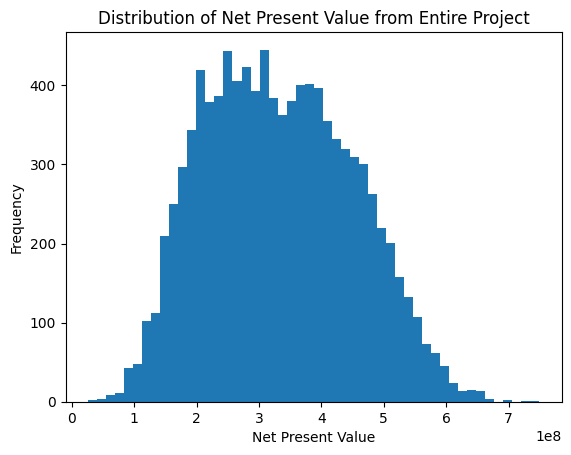

Mean NPV for Entire Project: 332646185.09539366
Min: 26240086.306530703
Max: 749030274.3773477


In [ ]:
npvs = []

#simulation is run 10000 times
for i in range(n_sim):


    ##Bring in hw1 to simulate drilling costs for 2025

    #normal distribution for 2006-2012
    years = 6

    mu = data['Change'].to_numpy().mean()
    sigma = data['Change'].to_numpy().std()

    r_6 = rng.normal(loc=mu, scale=sigma, size=years)
    P6_normal = P0 * np.prod(1 + r_6)

    #2012 - 2015
    sim_12_15 = rng.uniform(-0.22, -0.07, size=3)

    #2015 - 2024
    sim_15_24 = rng.uniform(0.02, 0.06, size=9)

    #2025
    sim_25 = rng.uniform(0.02, 0.06, size=1)

    #concatenate these into an array
    future_changes = np.concatenate([sim_12_15, sim_15_24, sim_25])

    #simulation with normal distribution for 2006-2012 time period
    P2025_normal = P6_normal * np.prod(1 + future_changes)


    #use median as drilling cost for 2025
    drilling_cost_2025 = (P2025_normal) * 1000


    ##Get operating costs for all the years

    #doing this outside of single well simulation bc this is the same for all wells, but could vary from year to year
    #calculating operating costs per year, since this is the same for every well but could change from year to year
    operating_costs = []
    for year in range(1, 16):
        year_operating_cost = rng.normal(2.25, 0.30)
        operating_costs.append(year_operating_cost)


    ##Now run simulation for wells to get npv

    #number of planned wells in the project is a uniform distribution between 10 and 30
    num_wells = rng.integers(10, 31)

    #this is where we simulate if the well is producing (1) or not producing (0)
    wells = rng.binomial(1, 0.85, size=num_wells)

    #simulate npv for all wells in project
    sim_npv = []
    for well in range(0, len(wells)):
        if wells[well] == 0:
            sim_npv.append(simulate_well_npv(drilling_cost_2025, False, operating_costs))
        else:
            sim_npv.append(simulate_well_npv(drilling_cost_2025, True, operating_costs))

    #add total npv for each project to list
    npvs.append(sum(sim_npv))


#create histogram of results
plt.hist(npvs, bins=50)
plt.xlabel("Net Present Value")
plt.ylabel("Frequency")
plt.title("Distribution of Net Present Value from Entire Project")
plt.show()

#some summary stats (not needed for anything specifically in assignment)
print("Mean NPV for Entire Project:", np.mean(npvs))
print("Min:", np.min(npvs))
print("Max:", np.max(npvs))

In [ ]:
##Get VAR and cVAR

confidence_levels = [0.90, 0.95, 0.99]
risk_rows = []

def dollar0(x):
    return f"${x:,.0f}"

def dollarM(x, pos=None):
    return f"${x/1_000_000:,.1f}M"

def pct1(x):
    return f"{100*x:.1f}%"

for conf in confidence_levels:
    alpha = 1 - conf
    var_threshold = np.quantile(npvs, alpha)
    cvar_threshold = np.mean([i for i in npvs if i <= var_threshold])
    risk_rows.append({
        "Confidence": pct1(conf),
        "Tail Probability": pct1(alpha),
        "VaR Threshold (NPV)": dollar0(var_threshold),
        "VaR Loss vs Mean": dollar0(np.mean(npvs) - var_threshold),
        "CVaR (Average Tail NPV)": dollar0(cvar_threshold),
        "CVaR Loss vs Mean": dollar0(np.mean(npvs) - cvar_threshold)
    })

risk_tbl = pd.DataFrame(risk_rows)
risk_tbl

,Confidence,Tail Probability,VaR Threshold (NPV),VaR Loss vs Mean,CVaR (Average Tail NPV),CVaR Loss vs Mean
0,90.0%,10.0%,"$182,368,741","$150,277,444","$147,846,547","$184,799,638"
1,95.0%,5.0%,"$154,213,838","$178,432,347","$127,037,932","$205,608,253"
2,99.0%,1.0%,"$109,823,762","$222,822,423","$90,025,216","$242,620,969"


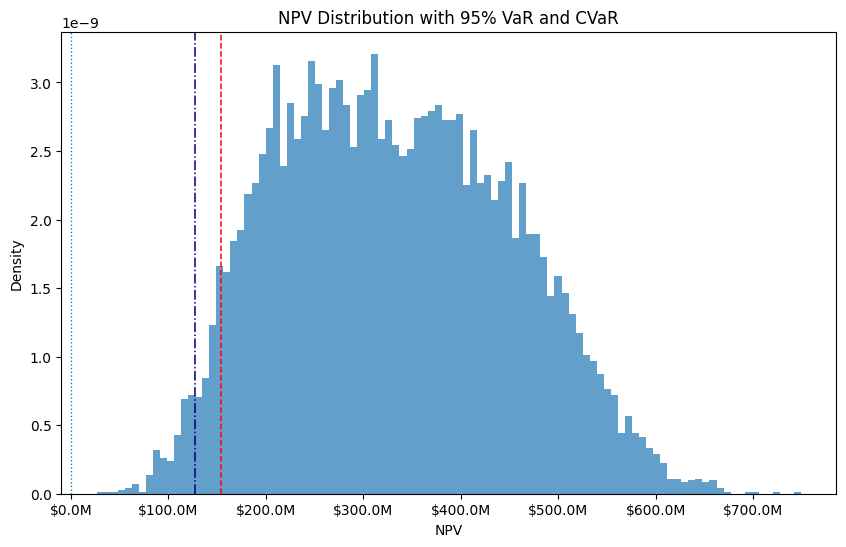

In [ ]:
##Visualize VAR and cVAR

var_95 = np.quantile(npvs, 0.05)
cvar_95 = np.mean([i for i in npvs if i <= np.quantile(npvs, 0.05)])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(npvs, bins=100, density=True, alpha=0.7)
ax.axvline(var_95, linestyle="--", linewidth=1.1, color='red')
ax.axvline(cvar_95, linestyle="-.", linewidth=1.1, color='navy')
ax.axvline(0, linestyle=":", linewidth=1)
ax.xaxis.set_major_formatter(FuncFormatter(dollarM))
ax.set_title("NPV Distribution with 95% VaR and CVaR")
ax.set_xlabel("NPV")
ax.set_ylabel("Density")
plt.show()

In [ ]:
print(var_95)
print(cvar_95)

154213838.2427565
127037932.27467588


In [ ]:
##Final Decision Scorecard

var_loss_95 = np.mean(npvs) - var_95
cvar_loss_95 = np.mean(npvs) - cvar_95

scorecard_tbl = pd.DataFrame({
    "Metric": [
        "Base-case NPV",
        "Mean simulated NPV",
        "Probability NPV > 0",
        "95% VaR loss vs mean",
        "95% CVaR loss vs mean"
    ],
    "Value": [
        dollar0(base_npv),
        dollar0(np.mean(npvs)),
        pct1(np.mean([i for i in npvs if i > 0])),
        dollar0(var_loss_95),
        dollar0(cvar_loss_95)
    ]
})

scorecard_tbl

,Metric,Value
0,Base-case NPV,"$331,066,180"
1,Mean simulated NPV,"$332,646,185"
2,Probability NPV > 0,33264618509.5%
3,95% VaR loss vs mean,"$178,432,347"
4,95% CVaR loss vs mean,"$205,608,253"


Initial Thoughts
<ul>
<li>Base Case NPV is positive indicating project is expected to be profitable</li>
<li>Mean Simulated NPV is positive confirming the probability on average</li>
</ul>

Recommendation: Good project to invest in as it seems to most likely be profitable!